In [13]:
import os
import sys
os.chdir("/Users/manasvisharma/Desktop/ecg-ml")
print("CWD:", os.getcwd())

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from src.models.cnn_model import ECGCNN
from src.data.label_utils import convert_to_binary

CWD: /Users/manasvisharma/Desktop/ecg-ml


In [4]:
X_raw = np.load("data/processed/X.npy")
y_raw = np.load("data/processed/y.npy")

y = convert_to_binary(y_raw)

print("Shape:", X_raw.shape)
print("Normal:", (y==0).sum(), "Abnormal:", (y==1).sum())

Shape: (10630, 360)
Normal: 6439 Abnormal: 4191


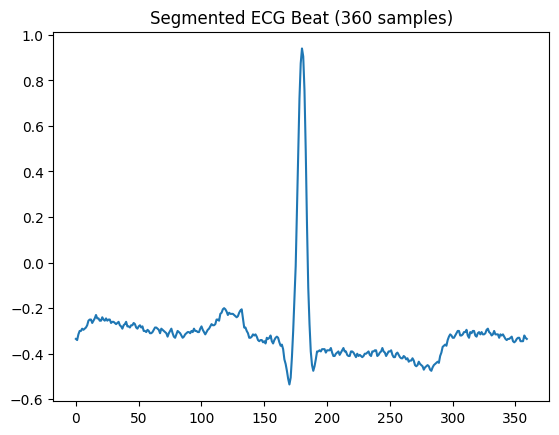

In [5]:
plt.plot(X_raw[0])
plt.title("Segmented ECG Beat (360 samples)")
plt.show()

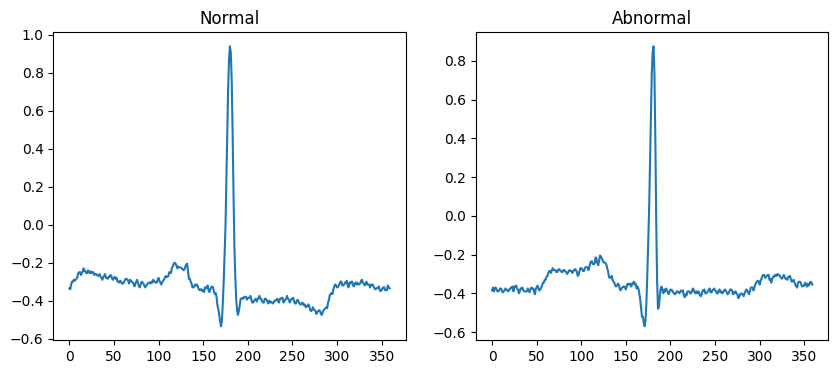

In [6]:
normal_idx = np.where(y == 0)[0][0]
abnormal_idx = np.where(y == 1)[0][0]

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(X_raw[normal_idx])
plt.title("Normal")

plt.subplot(1,2,2)
plt.plot(X_raw[abnormal_idx])
plt.title("Abnormal")

plt.show()

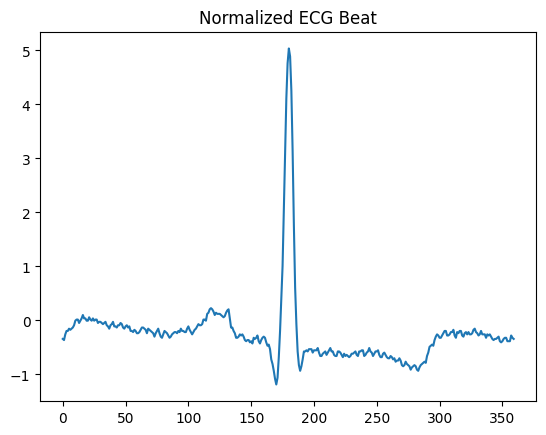

In [7]:
X = (X_raw - X_raw.mean()) / X_raw.std()

plt.plot(X[0])
plt.title("Normalized ECG Beat")
plt.show()

In [8]:
device = torch.device("cpu")

model = ECGCNN(num_classes=2)
model.load_state_dict(torch.load("results/models/best_cnn.pth", map_location=device))
model.eval()

print("Model loaded")

Model loaded


In [9]:
X_tensor = torch.tensor(X[:1000], dtype=torch.float32)

with torch.no_grad():
    outputs = model(X_tensor)
    probs = torch.softmax(outputs, dim=1)
    _, preds = torch.max(outputs, 1)

preds = preds.numpy()
probs = probs[:,1].numpy()
y_sample = y[:1000]

In [10]:
print(classification_report(y_sample, preds))

roc_auc = roc_auc_score(y_sample, probs)
print("ROC-AUC:", roc_auc)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       993
           1       1.00      1.00      1.00         7

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

ROC-AUC: 1.0


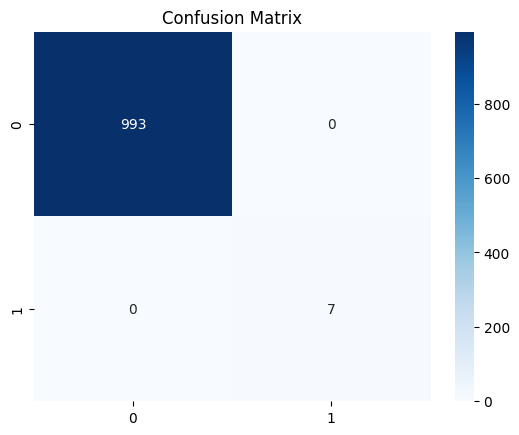

In [11]:
cm = confusion_matrix(y_sample, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

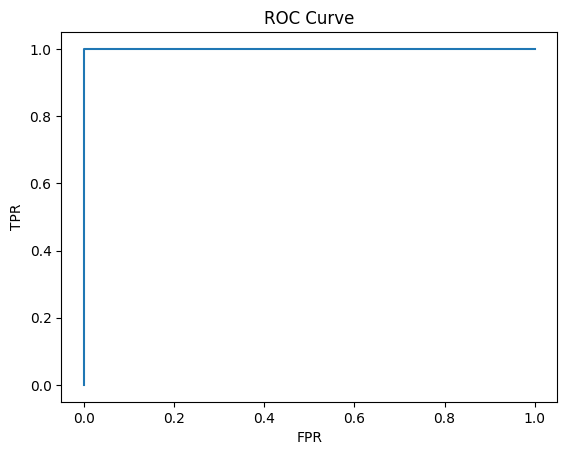

In [12]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_sample, probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()